In [1]:
# Imports and global settings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme()
pd.set_option('display.float_format', '{:.3f}'.format)
RANDOM_STATE = 42


## Part 1 — Fixed 15-Minute Horizon


In [2]:
# Load the prepared forecasting datasets
train_df = pd.read_csv('../Data/train_forecast.csv')
val_df = pd.read_csv('../Data/val_forecast.csv')

print(train_df.shape)
print(val_df.shape)


(65823, 25)
(16299, 25)


In [3]:
# Feature list: nowcasting features extended with lag features
# Power[kW], target_1hour, isSun, sunlightTime, SunlightTime/daylength, weather_type, and Time
# are deliberately excluded - Power[kW] would leak the answer almost directly since
# power_lag1 already captures it, and the others repeat information already covered elsewhere
features = ['GHI', 'temp', 'pressure', 'humidity', 'wind_speed',
            'rain_1h', 'snow_1h', 'clouds_all', 'dayLength',
            'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
            'power_lag1', 'power_lag2', 'power_lag4', 'power_roll4']
target = 'target_15min'


In [4]:
# Build feature matrices and target vectors
X_train = train_df[features]
y_train = train_df[target]
X_val = val_df[features]
y_val = val_df[target]

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_train.columns)


(65823, 17) (65823,)
(16299, 17) (16299,)
Index(['GHI', 'temp', 'pressure', 'humidity', 'wind_speed', 'rain_1h',
       'snow_1h', 'clouds_all', 'dayLength', 'hour_sin', 'hour_cos',
       'month_sin', 'month_cos', 'power_lag1', 'power_lag2', 'power_lag4',
       'power_roll4'],
      dtype='str')


In [5]:
# Regression metrics helper
def regression_report(y_true, y_pred, label=''):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f'{label}  RMSE={rmse:,.3f}  MAE={mae:,.3f}  R2={r2:.3f}')
    return rmse, mae, r2


In [6]:
# Persistence baseline for reference: predict Power[kW] as the 15-min forecast
persistence_pred_val = val_df['Power[kW]']
persistence_rmse, persistence_mae, persistence_r2 = regression_report(y_val, persistence_pred_val, label='15-min persistence baseline')


15-min persistence baseline  RMSE=1.796  MAE=0.997  R2=0.854


In [7]:
# Fit a Random Forest using the min_samples_leaf found in the nowcasting sweep
rf = RandomForestRegressor(n_estimators=300, min_samples_leaf=10,
                            random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)

train_rmse, train_mae, train_r2 = regression_report(y_train, rf.predict(X_train), label='RF train')
val_rmse, val_mae, val_r2 = regression_report(y_val, rf.predict(X_val), label='RF val')


RF train  RMSE=1.227  MAE=0.671  R2=0.940
RF val  RMSE=1.584  MAE=0.890  R2=0.886


       feature  importance
0  power_roll4       0.862
1     hour_sin       0.042
2          GHI       0.036
3   power_lag1       0.013
4   power_lag2       0.009
5    dayLength       0.008
6   power_lag4       0.007
7   clouds_all       0.005


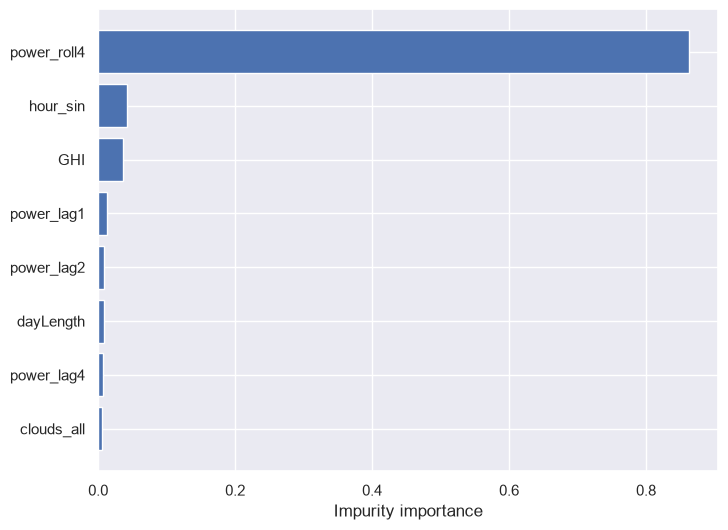

In [8]:
# Top 8 feature importances, sorted
importance_df = pd.DataFrame({'feature': features, 'importance': rf.feature_importances_})
importance_df = importance_df.sort_values('importance', ascending=False).reset_index(drop=True)
top8 = importance_df.head(8)
print(top8)

plt.figure(figsize=(8, 6))
plt.barh(top8['feature'], top8['importance'])
plt.xlabel('Impurity importance')
plt.gca().invert_yaxis()
plt.show()


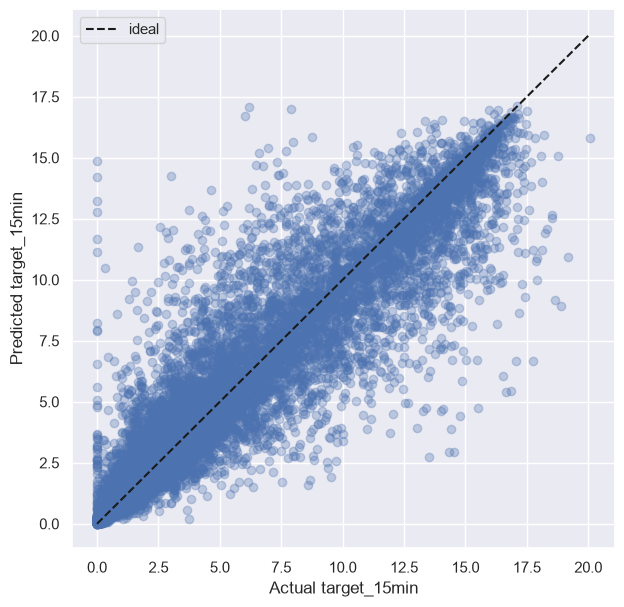

In [9]:
# Predicted vs actual scatter for the validation set
val_pred = rf.predict(X_val)

plt.figure(figsize=(7, 7))
plt.scatter(y_val, val_pred, alpha=0.3)
lims = [min(y_val.min(), val_pred.min()), max(y_val.max(), val_pred.max())]
plt.plot(lims, lims, 'k--', label='ideal')
plt.xlabel('Actual target_15min')
plt.ylabel('Predicted target_15min')
plt.legend()
plt.show()


In [10]:
# Final comparison for Part 1: persistence baseline versus Random Forest
comparison_rows = []
comparison_rows.append({'model': 'Persistence baseline', 'RMSE': persistence_rmse, 'MAE': persistence_mae, 'R2': persistence_r2})
comparison_rows.append({'model': 'Random Forest', 'RMSE': val_rmse, 'MAE': val_mae, 'R2': val_r2})

comparison_df = pd.DataFrame(comparison_rows)
print(comparison_df)


                  model  RMSE   MAE    R2
0  Persistence baseline 1.796 0.997 0.854
1         Random Forest 1.584 0.890 0.886


## Part 2 — Flexible Multi-Horizon


In [11]:
# Load the original nowcasting train and validation sets, parsing and sorting by Time
train_raw_df = pd.read_csv('../Data/train.csv')
val_raw_df = pd.read_csv('../Data/val.csv')

train_raw_df['Time'] = pd.to_datetime(train_raw_df['Time'], format='mixed', errors='coerce')
val_raw_df['Time'] = pd.to_datetime(val_raw_df['Time'], format='mixed', errors='coerce')

train_raw_df = train_raw_df.sort_values('Time').reset_index(drop=True)
val_raw_df = val_raw_df.sort_values('Time').reset_index(drop=True)


In [12]:
# Build a stacked multi-horizon dataset: one copy of each dataframe per horizon, with its own target
horizon_list = [1, 2, 3, 4, 5, 6, 7, 8]

train_copies = []
for horizon in horizon_list:
    train_copy = train_raw_df.copy()
    train_copy['horizon_steps'] = horizon
    train_copy['target'] = train_copy['Power[kW]'].shift(-horizon)
    train_copies.append(train_copy)

val_copies = []
for horizon in horizon_list:
    val_copy = val_raw_df.copy()
    val_copy['horizon_steps'] = horizon
    val_copy['target'] = val_copy['Power[kW]'].shift(-horizon)
    val_copies.append(val_copy)

train_expanded = pd.concat(train_copies, ignore_index=True)
val_expanded = pd.concat(val_copies, ignore_index=True)


In [13]:
# Drop rows with no target (tail rows without enough future data for their horizon)
train_rows_before = len(train_expanded)
val_rows_before = len(val_expanded)

train_expanded = train_expanded.dropna(subset=['target']).reset_index(drop=True)
val_expanded = val_expanded.dropna(subset=['target']).reset_index(drop=True)

print('Train rows before:', train_rows_before, 'after:', len(train_expanded))
print('Val rows before:', val_rows_before, 'after:', len(val_expanded))

print(train_expanded.groupby('horizon_steps').size())
print(val_expanded.groupby('horizon_steps').size())


Train rows before: 573176 after: 573140
Val rows before: 141880 after: 141844
horizon_steps
1    71646
2    71645
3    71644
4    71643
5    71642
6    71641
7    71640
8    71639
dtype: int64
horizon_steps
1    17734
2    17733
3    17732
4    17731
5    17730
6    17729
7    17728
8    17727
dtype: int64


In [14]:
# Feature list for the multi-horizon model: weather and time-of-year features plus horizon_steps
# This variant has no lag features, so it may perform somewhat worse than Part 1 at the
# 15-min horizon specifically, since it lacks recent production history.
# 2 hours is the maximum horizon offered, since this model assumes the weather input stays
# valid throughout the forecast window - longer horizons would require actual forecasted
# weather, not current weather, which is out of scope here
features_multi = ['GHI', 'temp', 'pressure', 'humidity', 'wind_speed',
                   'rain_1h', 'snow_1h', 'clouds_all', 'dayLength',
                   'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
                   'horizon_steps']


In [15]:
# Build feature matrices and target vectors from the expanded multi-horizon data
X_train_multi = train_expanded[features_multi]
y_train_multi = train_expanded['target']
X_val_multi = val_expanded[features_multi]
y_val_multi = val_expanded['target']

print(X_train_multi.shape, y_train_multi.shape)
print(X_val_multi.shape, y_val_multi.shape)


(573140, 14) (573140,)
(141844, 14) (141844,)


In [16]:
# Fit a second Random Forest, with a new variable name to avoid overwriting Part 1's model
rf_multi = RandomForestRegressor(n_estimators=300, min_samples_leaf=10,
                                  random_state=RANDOM_STATE, n_jobs=-1)
rf_multi.fit(X_train_multi, y_train_multi)

train_multi_rmse, train_multi_mae, train_multi_r2 = regression_report(y_train_multi, rf_multi.predict(X_train_multi), label='RF multi train (all horizons)')
val_multi_rmse, val_multi_mae, val_multi_r2 = regression_report(y_val_multi, rf_multi.predict(X_val_multi), label='RF multi val (all horizons)')


RF multi train (all horizons)  RMSE=1.339  MAE=0.772  R2=0.927
RF multi val (all horizons)  RMSE=2.244  MAE=1.368  R2=0.768


In [17]:
# Evaluate validation performance separately for each horizon, labeled in minutes/hours
horizon_labels = {1: '15min', 2: '30min', 3: '45min', 4: '1hr', 5: '1hr15min', 6: '1hr30min', 7: '1hr45min', 8: '2hr'}
horizon_reports = []
for horizon in horizon_list:
    mask = val_expanded['horizon_steps'] == horizon
    X_val_horizon = X_val_multi[mask]
    y_val_horizon = y_val_multi[mask]
    val_pred_horizon = rf_multi.predict(X_val_horizon)
    label = 'RF multi val horizon=' + horizon_labels[horizon]
    horizon_rmse, horizon_mae, horizon_r2 = regression_report(y_val_horizon, val_pred_horizon, label=label)
    horizon_reports.append({'horizon': horizon_labels[horizon], 'RMSE': horizon_rmse, 'MAE': horizon_mae, 'R2': horizon_r2})


RF multi val horizon=15min  RMSE=1.829  MAE=1.090  R2=0.846
RF multi val horizon=30min  RMSE=1.980  MAE=1.175  R2=0.819
RF multi val horizon=45min  RMSE=2.110  MAE=1.276  R2=0.795
RF multi val horizon=1hr  RMSE=2.214  MAE=1.347  R2=0.774
RF multi val horizon=1hr15min  RMSE=2.326  MAE=1.438  R2=0.751
RF multi val horizon=1hr30min  RMSE=2.401  MAE=1.484  R2=0.734
RF multi val horizon=1hr45min  RMSE=2.468  MAE=1.542  R2=0.719
RF multi val horizon=2hr  RMSE=2.526  MAE=1.589  R2=0.706


          feature  importance
0             GHI       0.611
1        hour_sin       0.166
2      clouds_all       0.039
3        hour_cos       0.038
4   horizon_steps       0.038
5            temp       0.023
6       dayLength       0.023
7      wind_speed       0.017
8        pressure       0.015
9        humidity       0.014
10      month_sin       0.008
11        rain_1h       0.005
12      month_cos       0.003
13        snow_1h       0.000


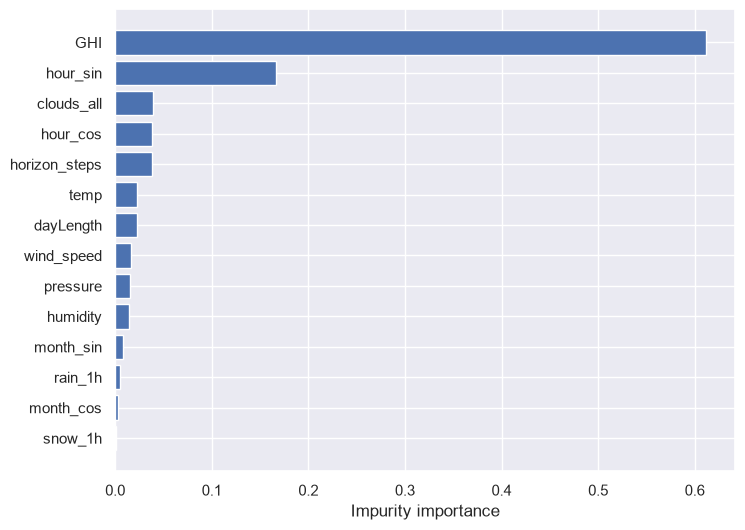

In [18]:
# Feature importances for the multi-horizon model - see where horizon_steps ranks relative to weather features
importance_multi_df = pd.DataFrame({'feature': features_multi, 'importance': rf_multi.feature_importances_})
importance_multi_df = importance_multi_df.sort_values('importance', ascending=False).reset_index(drop=True)
print(importance_multi_df)

plt.figure(figsize=(8, 6))
plt.barh(importance_multi_df['feature'], importance_multi_df['importance'])
plt.xlabel('Impurity importance')
plt.gca().invert_yaxis()
plt.show()


In [19]:
# Final combined comparison: persistence baseline, Part 1 fixed 15-min model, and Part 2 multi-horizon model
final_rows = []
final_rows.append({'model': 'Persistence baseline (15min)', 'RMSE': persistence_rmse, 'MAE': persistence_mae, 'R2': persistence_r2})
final_rows.append({'model': 'Part 1 Random Forest (fixed 15min, with lag)', 'RMSE': val_rmse, 'MAE': val_mae, 'R2': val_r2})
for row in horizon_reports:
    final_rows.append({'model': 'Part 2 Random Forest (' + row['horizon'] + ')', 'RMSE': row['RMSE'], 'MAE': row['MAE'], 'R2': row['R2']})

final_comparison_df = pd.DataFrame(final_rows)
print(final_comparison_df)


                                          model  RMSE   MAE    R2
0                  Persistence baseline (15min) 1.796 0.997 0.854
1  Part 1 Random Forest (fixed 15min, with lag) 1.584 0.890 0.886
2                  Part 2 Random Forest (15min) 1.829 1.090 0.846
3                  Part 2 Random Forest (30min) 1.980 1.175 0.819
4                  Part 2 Random Forest (45min) 2.110 1.276 0.795
5                    Part 2 Random Forest (1hr) 2.214 1.347 0.774
6               Part 2 Random Forest (1hr15min) 2.326 1.438 0.751
7               Part 2 Random Forest (1hr30min) 2.401 1.484 0.734
8               Part 2 Random Forest (1hr45min) 2.468 1.542 0.719
9                    Part 2 Random Forest (2hr) 2.526 1.589 0.706
